MNIST dataset with torch neural network

In [1]:
# import all the required dependencies
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Define transformation for the images
transform = transforms.Compose(
    [
        transforms.ToTensor(),  # Convert images to PyTorch tensors
        transforms.Normalize((0.1307,), (0.3081,)),  # Normalize with MNIST mean and std
    ]
)

In [3]:
# Load training dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data", # Where to store dataset
    train= True, # This is training data
    download=True, # Download if not present
    transform=transform # Apply transformation on downloaded dataset
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", # Where to store the dataset
    train=False, # This is testing dataset
    download=True, #
    transform=transform
)

# Create data loaders for batch processing
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [4]:
# Function to display images
def show_images(images, labels):
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(10):
        axes[i].imshow(images[i].reshape(28, 28), cmap="gray")
        axes[i].set_title(f"Label:{labels[i]}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

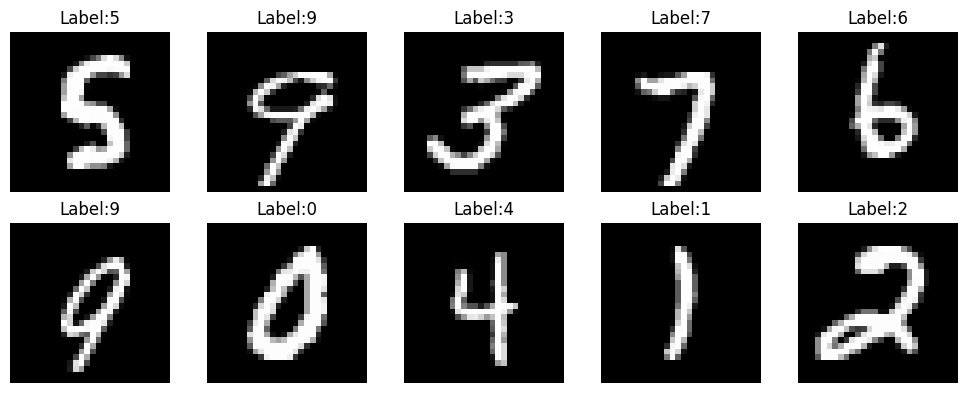

In [5]:
# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
show_images(images[:10], labels[:10])

In [11]:
# Create neural network model
class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)
        return x

In [12]:
# initize the model
model = SimpleNN()
print(model)

SimpleNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print(f"Is cuda available: {torch.cuda.is_available()}")
# Check if GPU is available
device_name = "cuda:0" if torch.cuda.is_available() else "cpu"

device = torch.device(device_name)
print(f"Using device for model training: {device}")
model.to(device)

# training loops
num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # backward pass and optimize
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if (i + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs}, Step[{i+1}/{len(train_loader)}], Loss:{running_loss/100:.4f}"
            )
            train_losses.append(running_loss / 100)
            running_loss = 0
print("Training finished!")

Is cuda available: True
Using device for model training: cuda:0
Epoch 1/5, Step[100/938], Loass:1.1484
Epoch 1/5, Step[200/938], Loass:0.3744
Epoch 1/5, Step[300/938], Loass:0.3162
Epoch 1/5, Step[400/938], Loass:0.2694
Epoch 1/5, Step[500/938], Loass:0.2375
Epoch 1/5, Step[600/938], Loass:0.1973
Epoch 1/5, Step[700/938], Loass:0.1912
Epoch 1/5, Step[800/938], Loass:0.1803
Epoch 1/5, Step[900/938], Loass:0.1607
Epoch 2/5, Step[100/938], Loass:0.1230
Epoch 2/5, Step[200/938], Loass:0.1237
Epoch 2/5, Step[300/938], Loass:0.1241
Epoch 2/5, Step[400/938], Loass:0.1200
Epoch 2/5, Step[500/938], Loass:0.0984
Epoch 2/5, Step[600/938], Loass:0.1044
Epoch 2/5, Step[700/938], Loass:0.1108
Epoch 2/5, Step[800/938], Loass:0.1017
Epoch 2/5, Step[900/938], Loass:0.0933
Epoch 3/5, Step[100/938], Loass:0.0771
Epoch 3/5, Step[200/938], Loass:0.0741
Epoch 3/5, Step[300/938], Loass:0.0781
Epoch 3/5, Step[400/938], Loass:0.0758
Epoch 3/5, Step[500/938], Loass:0.0833
Epoch 3/5, Step[600/938], Loass:0.0772


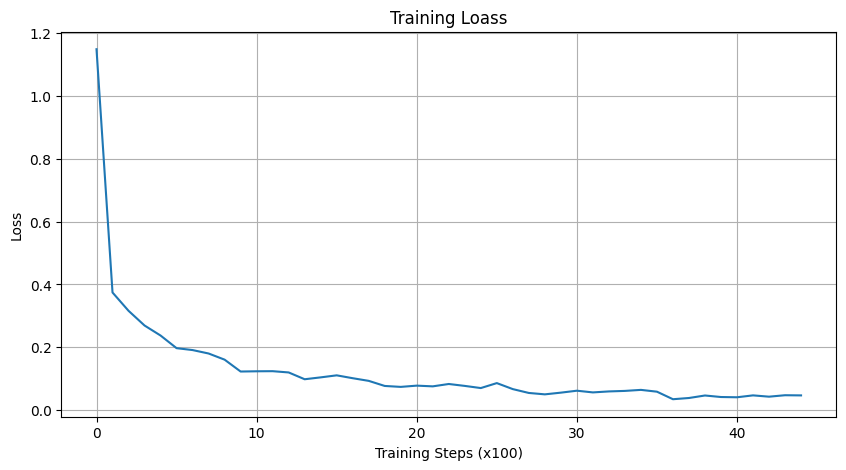

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title("Training Loass")
plt.xlabel("Training Steps (x100)")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [16]:
# 5. Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Accuracy on the test set: {accuracy:.2f}")

Accuracy on the test set: 97.91


In [ ]:
# Function to show predictions
def show_predictions(images, labels, preds):
    length = len(preds);
    print(length)
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    axes = axes.flatten()

    for i in range(length):
        axes[i].imshow(images[i].cpu().reshape(28, 28), cmap="gray")
        color = "green" if preds[i] == labels[i] else "red"
        axes[i].set_title(f"Pred:{preds[i]}, True: {labels[i]}", color=color)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

10


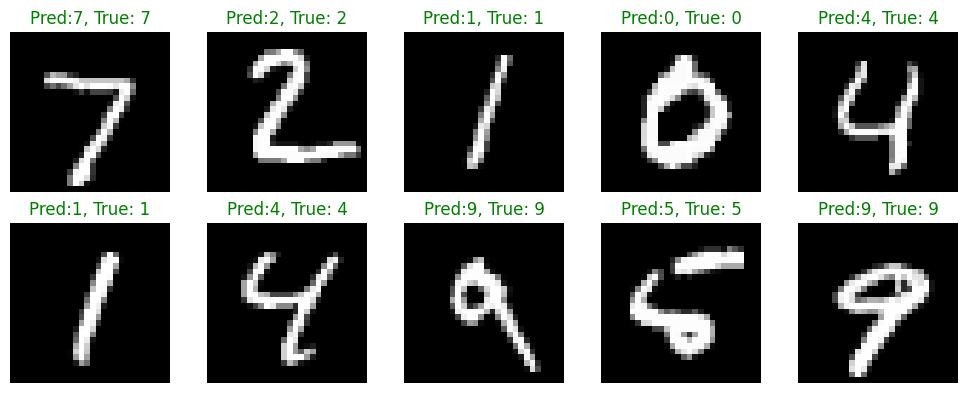

In [37]:
# Get predictions for some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

show_predictions(images[:10], labels[:10], preds[:10])

In [38]:
#Save the model so you can reuse instead of training each time before prediction

torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved succesfully.")

Model saved succesfully.


In [2]:
# Load model
loaded_model = SimpleNN()
loaded_model.load_state_dict(torch.load("mnist_model.pth"))
loaded_model.to(device)
loaded_model.eval()
print("Model Loaded !")


NameError: name 'SimpleNN' is not defined

10


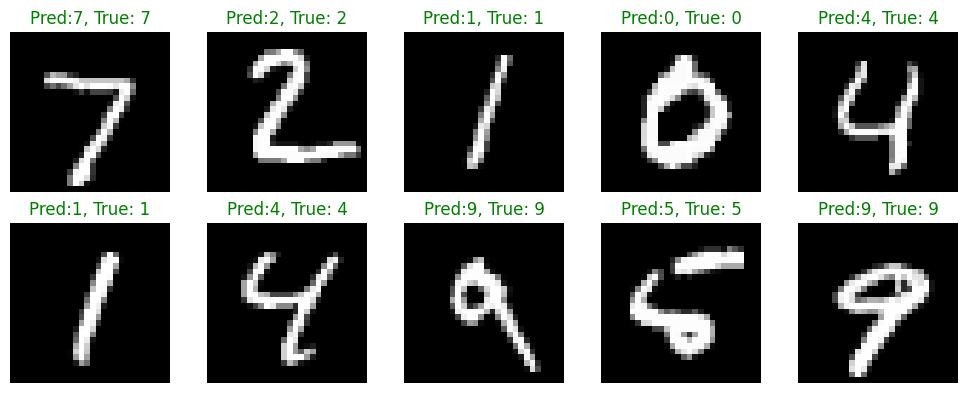

In [40]:
# Get predictions for some test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = loaded_model(images)
_, preds = torch.max(outputs, 1)

show_predictions(images[:10], labels[:10], preds[:10])